In [ ]:
lfrom google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [ ]:
male_path = "/content/drive/MyDrive/GenderClassification/dataset/male1"
female_path = "/content/drive/MyDrive/GenderClassification/dataset/female1"

In [ ]:
data = []
labels = []
IMG_SIZE = (100, 100)

# Load Male Images
for img_name in os.listdir(male_path):
    img_path = os.path.join(male_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, IMG_SIZE)
        data.append(img)
        labels.append(0)   # 0 for Male

# Load Female Images
for img_name in os.listdir(female_path):
    img_path = os.path.join(female_path, img_name)
    img = cv2.imread(img_path)
    if img is not None:
        img = cv2.resize(img, IMG_SIZE)
        data.append(img)
        labels.append(1)   # 1 for Female

data = np.array(data)
labels = np.array(labels)

print("Loaded images:", data.shape)
print("Labels:", labels.shape)


✅ Loaded images: (23708, 100, 100, 3)
✅ Labels: (23708,)


In [ ]:
data_hsv = np.array([cv2.cvtColor(img, cv2.COLOR_BGR2HSV) for img in data])
print("Converted to HSV:", data_hsv.shape)

✅ Converted to HSV: (23708, 100, 100, 3)


In [ ]:
def safe_skew(x):
              return skew(x) if np.std(x) > 1e-3 else 0
def safe_kurtosis(x):
              return kurtosis(x) if np.std(x) > 1e-3 else 0
features = []

for img in data_hsv:
    h, s, v = cv2.split(img)

    # Flatten to 1D arrays
    h_flat, s_flat, v_flat = h.flatten(), s.flatten(), v.flatten()

    def channel_features(channel):
        hist, _ = np.histogram(channel, bins=256, range=(0,256))
        hist = hist / np.sum(hist)
        return
         [
            np.mean(channel),
            np.std(channel),
            safe_skew(channel),
            safe_kurtosis(channel),
            entropy(hist + 1e-10),  # Add epsilon to avoid log(0)
            np.median(channel),
            np.max(channel) - np.min(channel)
        ]

    # Compute all features for H, S, and V channels
    h_feat = channel_features(h_flat)
    s_feat = channel_features(s_flat)
    v_feat = channel_features(v_flat)

    # Combine all features into a single list
    all_features = h_feat + s_feat + v_feat
    features.append(all_features)

features = np.array(features)

print("Feature matrix shape:", features.shape)
print("Each image has", features.shape[1], "features now.")


✅ Feature matrix shape: (23708, 21)
Each image has 21 features now.


In [ ]:
np.save("/content/drive/MyDrive/GenderClassification/features.npy", features)
np.save("/content/drive/MyDrive/GenderClassification/labels.npy", labels)

print("Features and labels saved successfully!")

✅ Features and labels saved successfully!


In [ ]:
binary_data = []

for img in data_hsv:
    h, s, v = cv2.split(img)

    # Apply thresholding on Value channel
    _, binary = cv2.threshold(v, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary_data.append(binary)

binary_data = np.array(binary_data)
print("Binary images created:", binary_data.shape)

✅ Binary images created: (23708, 100, 100)


In [ ]:
save_dir = "/content/drive/MyDrive/GenderClassification/binary_images"
os.makedirs(save_dir, exist_ok=True)

for i, binary_img in enumerate(binary_data):
    cv2.imwrite(f"{save_dir}/binary_{i}.jpg", binary_img)

print(f"Saved {len(binary_data)} binary images to {save_dir}")

KeyboardInterrupt: 

In [ ]:
enhanced_features = []

for i in range(len(data_hsv)):
    # Existing HSV features
    h, s, v = cv2.split(data_hsv[i])
    h_flat, s_flat, v_flat = h.flatten(), s.flatten(), v.flatten()

    def channel_features(channel):
        hist, _ = np.histogram(channel, bins=256, range=(0,256))
        hist = hist / np.sum(hist)
        return [
            np.mean(channel),
            np.std(channel),
            skew(channel) if np.std(channel) > 1e-3 else 0,
            kurtosis(channel) if np.std(channel) > 1e-3 else 0,
            entropy(hist + 1e-10),
            np.median(channel),
            np.max(channel) - np.min(channel)
        ]

    hsv_feats = channel_features(h_flat) + channel_features(s_flat) + channel_features(v_flat)

    # Binary image
    binary = binary_data[i]
    white_ratio = np.sum(binary == 255) / binary.size
    black_ratio = np.sum(binary == 0) / binary.size

    # edge density
    edges = cv2.Canny(binary, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    # Combine all features
    combined = hsv_feats + [white_ratio, black_ratio, edge_density]
    enhanced_features.append(combined)

enhanced_features = np.array(enhanced_features)
print("Combined HSV + Binary feature shape:", enhanced_features.shape)

✅ Combined HSV + Binary feature shape: (23708, 24)


In [ ]:
save_path = "/content/drive/MyDrive/GenderClassification/enhanced_features_labels.npz"

np.savez(save_path, features=enhanced_features, labels=labels)
print(f"Features and labels saved at: {save_path}")


✅ Features and labels saved at: /content/drive/MyDrive/GenderClassification/enhanced_features_labels.npz


In [ ]:
data = np.load("/content/drive/MyDrive/GenderClassification/enhanced_features_labels.npz")
X = data['features']
Y = data['labels']

print("Loaded features and labels:", X.shape, Y.shape)

✅ Loaded features and labels: (23708, 24) (23708,)


In [ ]:
X = data["features"]
Y = data["labels"]

print("Loaded features:", X.shape)
print("Loaded labels:", Y.shape)

X_train, X_test, Y_train, Y_test = train_test_split
 (
    X, Y, test_size=0.2, random_state=42, stratify=Y
 )
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

✅ Loaded features: (23708, 24)
✅ Loaded labels: (23708,)
Train shape: (18966, 24) Test shape: (4742, 24)


In [ ]:
model = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

✅ Accuracy: 0.6971741881062843

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.75      0.72      2478
           1       0.70      0.63      0.67      2264

    accuracy                           0.70      4742
   macro avg       0.70      0.69      0.69      4742
weighted avg       0.70      0.70      0.70      4742


Confusion Matrix:
 [[1869  609]
 [ 827 1437]]


In [ ]:
joblib.dump((model, scaler), "/content/drive/MyDrive/GenderClassification/gender_svm_model.pkl")
print("Model and scaler saved to Drive")

NameError: name 'model' is not defined

In [ ]:
model, scaler = joblib.load("/content/drive/MyDrive/GenderClassification/gender_svm_model.pkl")
print("Model and scaler loaded")

✅ Model and scaler loaded


test_face1.jpg: Male (70.8% confidence)


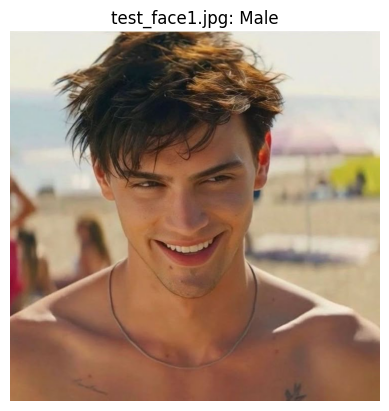

test_face2.jpg: Male (64.5% confidence)


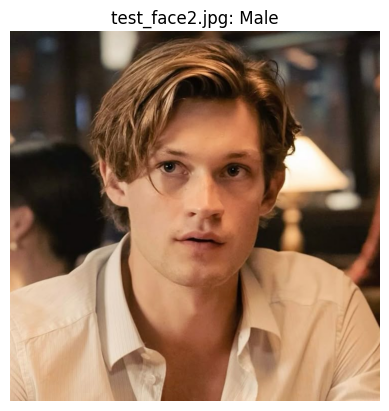

test_face3.jpg: Male (88.5% confidence)


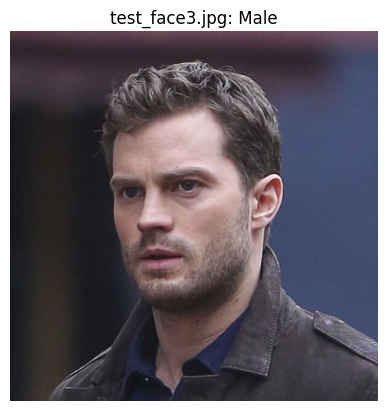

test_face4.jpg: Female (69.3% confidence)


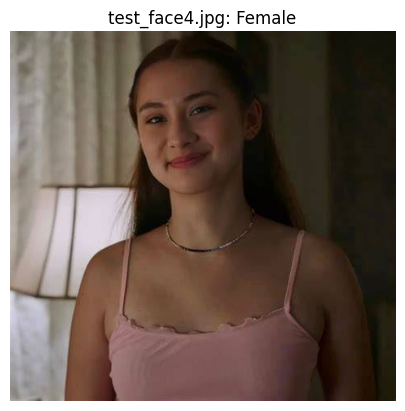

test_face5.jpg: Female (51.6% confidence)


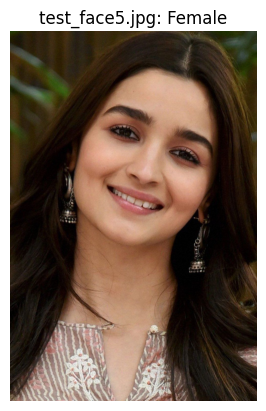

In [ ]:
test_folder = "/content/drive/MyDrive/GenderClassification/test"

for img_name in os.listdir(test_folder):
    img_path = os.path.join(test_folder, img_name)
    orig = cv2.imread(img_path)
    if orig is None:
        continue
    img = cv2.resize(orig, (100, 100))
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(img_hsv)
    _, binary = cv2.threshold(v, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Features
    h_feat = channel_features(h.flatten())
    s_feat = channel_features(s.flatten())
    v_feat = channel_features(v.flatten())
    white_ratio = np.sum(binary == 255) / binary.size
    black_ratio = np.sum(binary == 0) / binary.size
    edges = cv2.Canny(binary, 100, 200)
    edge_density = np.sum(edges > 0) / edges.size

    features = np.array(h_feat + s_feat + v_feat + [white_ratio, black_ratio, edge_density]).reshape(1, -1)
    features_scaled = scaler.transform(features)
    pred = model.predict(features_scaled)[0]
    prob = model.predict_proba(features_scaled)[0]

    label = "Male" if pred == 0 else "Female"
    print(f"{img_name}: {label} ({prob[pred]*100:.1f}% confidence)")

    plt.imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
    plt.title(f"{img_name}: {label}")
    plt.show()